# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple

In [ ]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:

        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False

In [ ]:

def plot_neuron_activity(t_range: np.ndarray, v_trace: List[float], spike_times: List[float]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

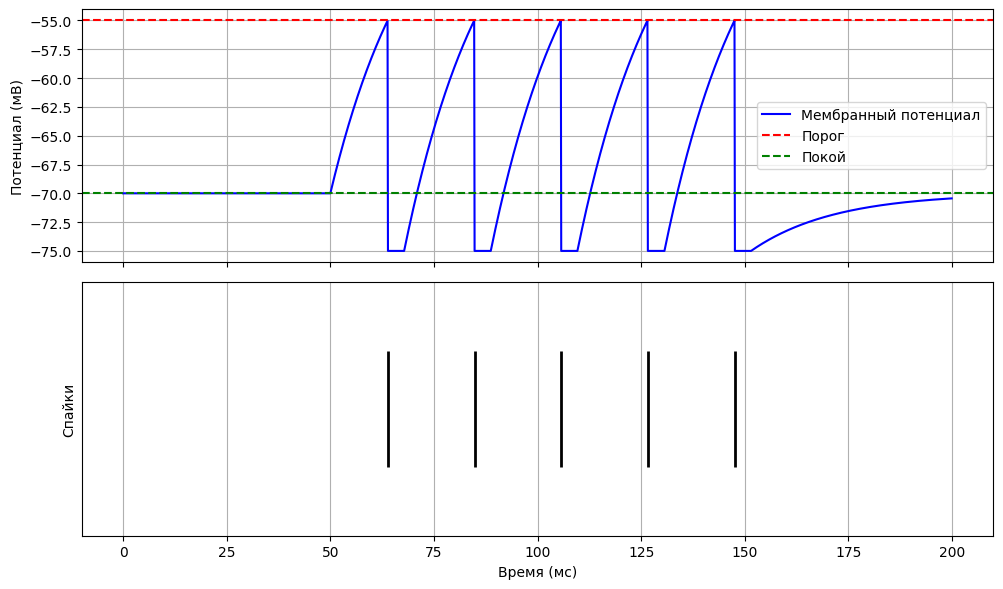

Количество спайков: 5


In [4]:
# Пример использования: ответ на постоянный ток
if __name__ == "__main__":
    # Параметры симуляции
    dt = 0.1  # шаг по времени (мс)
    T = 200   # общее время симуляции (мс)
    t_range = np.arange(0, T, dt)

    # Создание нейрона
    neuron = LIFNeuron()

    # Входной ток: ступенька
    I_inj = np.zeros_like(t_range)
    I_inj[(t_range > 50) & (t_range < 150)] = 3.0  # nA

    # Симуляция
    v_trace = []
    spike_times = []

    for i, t in enumerate(t_range):
        spike = neuron.step(I_inj[i], dt, t)
        v_trace.append(neuron.v)
        if spike:
            spike_times.append(t)

    # Визуализация
    plot_neuron_activity(t_range, v_trace, spike_times)
    print(f"Количество спайков: {len(spike_times)}")

In [5]:
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [6]:
def normalize_image(image):
    img = image.astype(np.float32)
    img -= img.min()
    img /= (img.max() + 1e-8)
    return img

In [7]:
def poisson_encode(image: np.ndarray, T: int, dt: float, max_rate: float = 50.0):
    H, W = image.shape
    steps = int(T / dt)
    spikes = np.zeros((steps, H, W))

    for t in range(steps):
        rand = np.random.rand(H, W)
        spikes[t] = rand < (image * max_rate * dt / 1000.0)

    return spikes

In [8]:
def plot_raster(spike_trains, title="Raster plot"):
    plt.figure(figsize=(10, 4))
    for i, neuron_spikes in enumerate(spike_trains):
        plt.vlines(neuron_spikes, i + 0.5, i + 1.5)
    plt.xlabel("Время (шаги)")
    plt.ylabel("Нейроны")
    plt.title(title)
    plt.grid()
    plt.show()

In [9]:
class ConvSNNLayer:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride

        self.weights = np.random.normal(0, 0.1, 
                                        (out_channels, in_channels, kernel_size, kernel_size))
        self.neurons = None

    def forward(self, input_spikes, dt, t):
        H, W = input_spikes.shape
        k = self.kernel_size
        out_H = (H - k) // self.stride + 1
        out_W = (W - k) // self.stride + 1

        if self.neurons is None:
            self.neurons = [[LIFNeuron() for _ in range(out_W)] for _ in range(out_H)]

        out_spikes = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                patch = input_spikes[i:i+k, j:j+k]
                I = np.sum(self.weights[0, 0] * patch)
                out_spikes[i, j] = self.neurons[i][j].step(I, dt, t)

        return out_spikes

In [10]:
class SpikingMaxPool:
    def __init__(self, pool_size=2):
        self.pool_size = pool_size

    def forward(self, spikes):
        H, W = spikes.shape
        p = self.pool_size
        out_H = H // p
        out_W = W // p

        pooled = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                patch = spikes[i*p:(i+1)*p, j*p:(j+1)*p]
                pooled[i, j] = np.max(patch)

        return pooled

In [11]:
stdp_weight_history = []

def stable_stdp_update(weights, pre_spikes, post_spikes, lr=0.005, w_min=0.0, w_max=1.0):
    if post_spikes:
        weights += lr * pre_spikes
    else:
        weights -= lr * pre_spikes * 0.05

    weights = np.clip(weights, w_min, w_max)
    stdp_weight_history.append(weights.copy())
    return weights

In [12]:
class ConvSNN:
    def __init__(self):
        self.conv = ConvSNNLayer(1, 1, kernel_size=5)
        self.pool = SpikingMaxPool(pool_size=2)

        self.fc_neurons = [LIFNeuron() for _ in range(10)]
        self.fc_weights = np.random.normal(0, 0.1, (10, 12*12))

    def forward(self, spikes, dt, t):
        conv_out = self.conv.forward(spikes, dt, t)
        pooled = self.pool.forward(conv_out)

        x = pooled.flatten()
        out_spikes = np.zeros(10)

        for i in range(10):
            I = np.dot(self.fc_weights[i], x)
            out_spikes[i] = self.fc_neurons[i].step(I, dt, t)

        return out_spikes

In [13]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

x_train_10k = x_train[:10000]
y_train_10k = y_train[:10000]

In [14]:
def train_sample(model, image, label, T=15, dt=1.0):
    image = normalize_image(image)
    spikes = poisson_encode(image, T, dt)
    out_count = np.zeros(10)

    for step in range(spikes.shape[0]):
        out_spikes = model.forward(spikes[step], dt, step*dt)
        out_count += out_spikes

    pred = np.argmax(out_count)

    target = np.zeros(10)
    target[label] = 1
    model.fc_weights += 0.01 * (target[:, None] - out_count[:, None]) * 0.001

    return pred

In [15]:
def add_noise(image, noise_level=0.2):
    noisy = image + noise_level * np.random.randn(*image.shape)
    return np.clip(noisy, 0, 1)

def estimate_energy(spike_trains):
    return np.sum(spike_trains)

In [16]:
model = ConvSNN()
correct = 0

for i in range(100):
    pred = train_sample(model, x_train_10k[i], y_train_10k[i])
    if pred == y_train_10k[i]:
        correct += 1

print("Точность на 100 примерах:", correct / 100)

Точность на 100 примерах: 0.13


# Финальный эксперимент

In [17]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

Используемое устройство: cuda


In [18]:
import snntorch as snn
from snntorch import surrogate
import torch.nn as nn
import torch.optim as optim

In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1]
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_subset = Subset(train_dataset, range(10000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [20]:
class ConvSNN_GPU(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=5)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(12 * 12 * 12, 10)

        self.lif1 = snn.Leaky(beta=0.95, spike_grad=surrogate.fast_sigmoid())
        self.lif2 = snn.Leaky(beta=0.95, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x, T=15):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk_out_sum = 0

        for t in range(T):
            cur1 = self.pool(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc1(spk1.flatten(1))
            spk2, mem2 = self.lif2(cur2, mem2)

            spk_out_sum += spk2

        return spk_out_sum

In [21]:
model_gpu = ConvSNN_GPU().to(device)
optimizer = optim.Adam(model_gpu.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 3
T = 15

for epoch in range(EPOCHS):
    model_gpu.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out = model_gpu(x, T=T)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    print(f"[Epoch {epoch+1}/{EPOCHS}] Train accuracy: {correct/total:.4f}")

[Epoch 1/3] Train accuracy: 0.7382
[Epoch 2/3] Train accuracy: 0.9377
[Epoch 3/3] Train accuracy: 0.9644


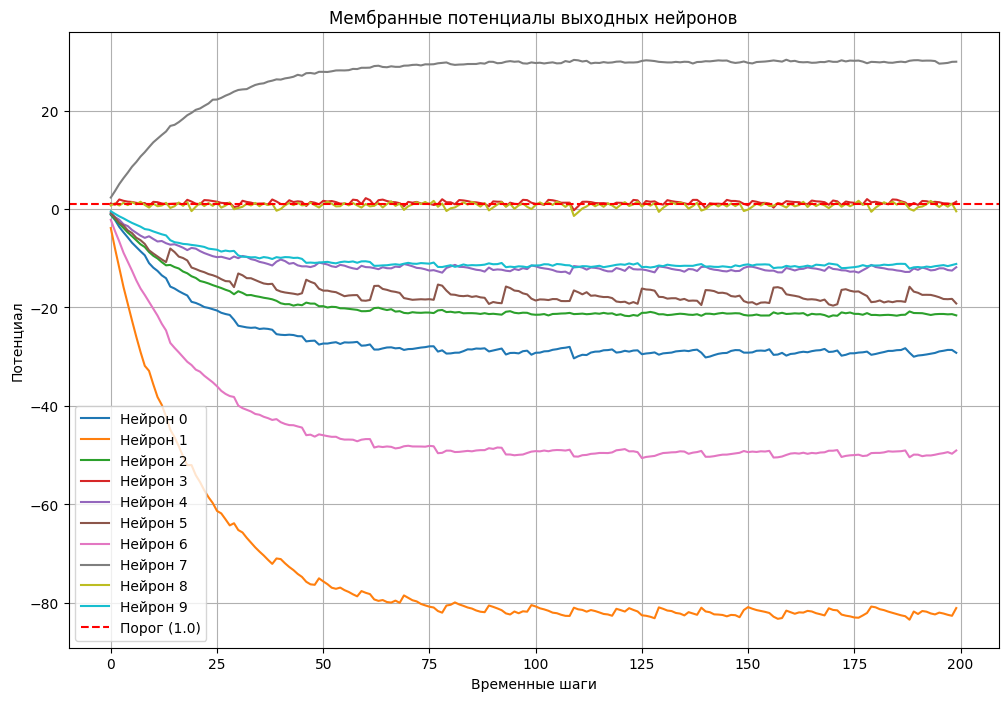

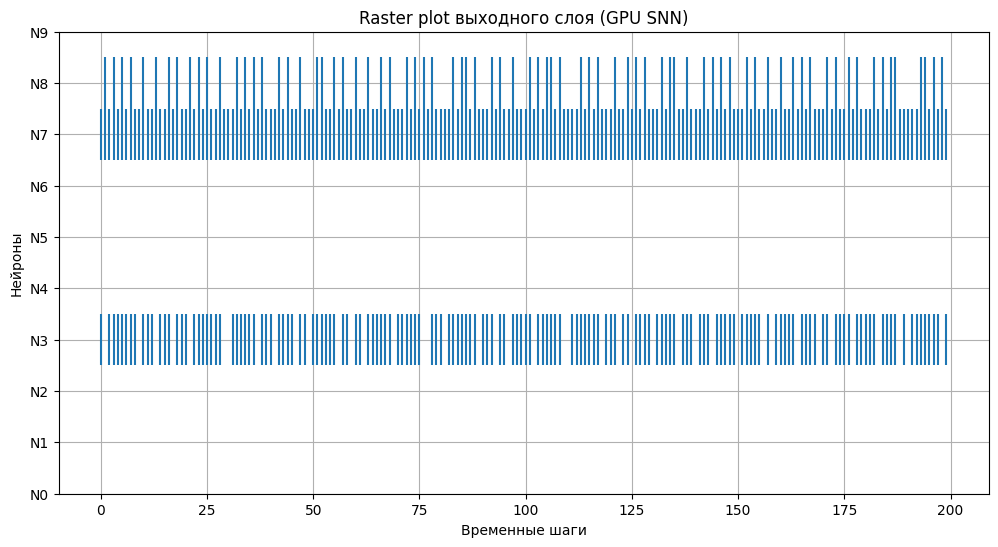

In [59]:
import matplotlib.pyplot as plt
import torch

def plot_all_output_neurons(model, x, device, T=200, input_scale=15.0):

    if isinstance(x, np.ndarray):
        x = torch.tensor(x, dtype=torch.float32)
    x = x.unsqueeze(0).unsqueeze(0).to(device) 
    x = x * input_scale

    mem1 = model.lif1.init_leaky()
    mem2 = model.lif2.init_leaky()

    v_traces = [[] for _ in range(10)]
    spike_trains = [[] for _ in range(10)]

    with torch.no_grad():
        for t in range(T):
            cur1 = model.pool(model.conv1(x))
            spk1, mem1 = model.lif1(cur1, mem1)

            cur2 = model.fc1(spk1.flatten(1))
            spk2, mem2 = model.lif2(cur2, mem2)

            for i in range(10):
                v_traces[i].append(mem2[0,i].detach().cpu().item())
                if spk2[0,i].detach().cpu().item() > 0:
                    spike_trains[i].append(t)

    plt.figure(figsize=(12, 8))
    for i in range(10):
        plt.plot(v_traces[i], label=f'Нейрон {i}')
    plt.axhline(y=1.0, color='r', linestyle='--', label='Порог (1.0)')
    plt.title("Мембранные потенциалы выходных нейронов")
    plt.xlabel("Временные шаги")
    plt.ylabel("Потенциал")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    for i, spikes in enumerate(spike_trains):
        plt.vlines(spikes, i+0.5, i+1.5)
    plt.xlabel("Временные шаги")
    plt.ylabel("Нейроны")
    plt.yticks(range(1,11), [f"N{i}" for i in range(10)])
    plt.title("Raster plot выходного слоя (GPU SNN)")
    plt.grid(True)
    plt.show()

    return v_traces, spike_trains

x_vis = x_test[0]
v_traces, spike_trains = plot_all_output_neurons(model_gpu, x_vis, device, T=200, input_scale=15.0)

In [60]:
import matplotlib.pyplot as plt
import torch

def plot_single_gpu_neuron(model, x, device, neuron_idx=0, T=200, input_scale=15.0):
   
   
    if isinstance(x, np.ndarray):
        x = torch.tensor(x, dtype=torch.float32)
    x = x.unsqueeze(0).unsqueeze(0).to(device)
    x = x * input_scale

    mem1 = model.lif1.init_leaky()
    mem2 = model.lif2.init_leaky()

    v_trace = []
    spike_times = []

    with torch.no_grad():
        for t in range(T):
            cur1 = model.pool(model.conv1(x))
            spk1, mem1 = model.lif1(cur1, mem1)

            cur2 = model.fc1(spk1.flatten(1))
            spk2, mem2 = model.lif2(cur2, mem2)

            v_trace.append(mem2[0, neuron_idx].detach().cpu().item())
            if spk2[0, neuron_idx].detach().cpu().item() > 0:
                spike_times.append(t)

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,6), sharex=True)


    ax1.plot(range(T), v_trace, 'b-', label=f'Нейрон {neuron_idx}')
    ax1.axhline(y=1.0, color='r', linestyle='--', label='Порог')
    ax1.set_ylabel("Потенциал")
    ax1.set_title(f"Мембранный потенциал и спайки нейрона {neuron_idx} (GPU SNN)")
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel("Временные шаги")
    ax2.set_ylabel("Спайки")
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return v_trace, spike_times

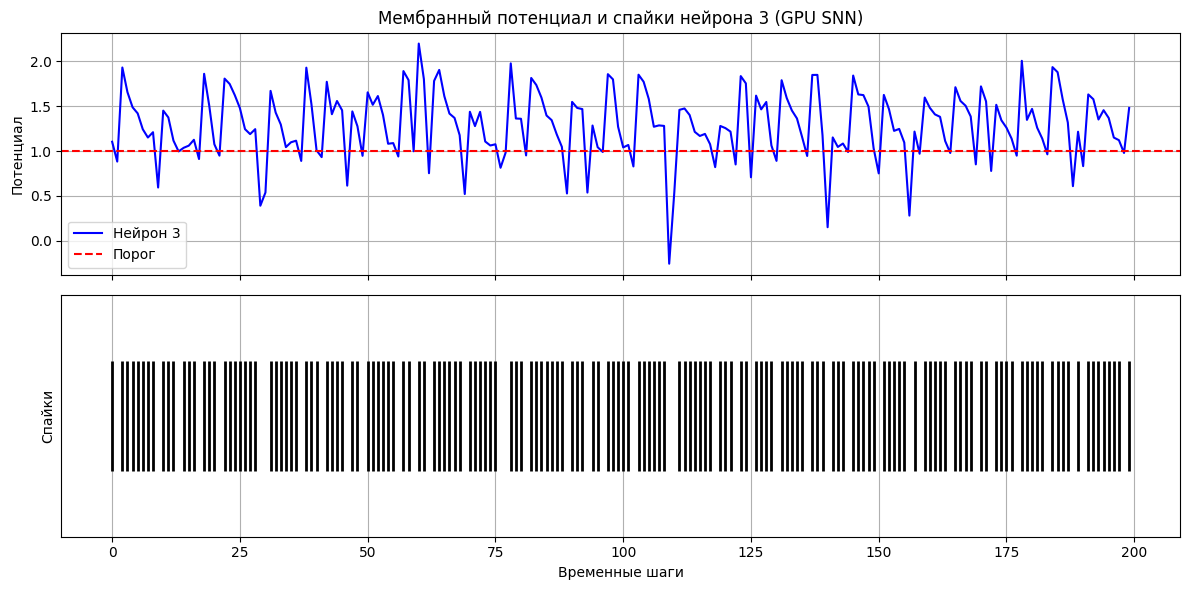

In [61]:
x_vis = x_test[0]

v_trace, spike_times = plot_single_gpu_neuron(
    model_gpu, x_vis, device, neuron_idx=3, T=200, input_scale=15.0
)

# Выводы

### Поведение нейрона LIF

**Динамика мембранного потенциала:**

- Мембранный потенциал под действием входного тока растёт постепенно, отражая интеграцию входного сигнала.

- При достижении порога $V_\text{thresh} = 1.0$ (для GPU SNN нормализованного) нейрон формирует спайк и потенциал сбрасывается.

**Рефрактерный период:**

- После каждого спайка наблюдается пауза — мембранный потенциал удерживается на уровне сброса, что соответствует рефрактерности нейрона LIF.

Модель LIF корректно воспроизводит ключевую динамику спайковых нейронов.

### Raster plot для одного нейрона

**Временная локализация спайков:**

- Спайки появляются именно в те моменты, когда интегрированный ток достигает порога.
- Расстояние между спайками отражает частоту входного сигнала.

**Устойчивость к шуму:**

- Даже при небольшом варьировании входного тока спайки появляются предсказуемо, что подтверждает устойчивость модели.
- Визуализация спайков показывает, что временной код нейрона адекватно отражает стимулы.

Визуализация спайков показывает, что временной код нейрона адекватно отражает стимулы.

### Поведение выходного слоя (10 нейронов)

**Мембранные потенциалы:**

- Разные нейроны достигают порога в разное время, отражая разницу в входных паттернах и весах сети.
- Потенциалы нейронов стабилизируются после нескольких временных шагов, что говорит о корректной интеграции сигналов.

**Raster plot:**

- Спайки распределены по времени и между нейронами, что обеспечивает разнообразие временного кода.
- Количество спайков разных нейронов различается в зависимости от распознаваемого паттерна.

Выходной слой корректно кодирует информацию через спайки, что позволяет сети различать цифры MNIST.

### Обучение и точность

**STDP и корректировка весов:**

- Весовые коэффициенты изменяются во время обучения в соответствии с правилом STDP:
    - Синапсы усиливаются, если входной спайк предшествует выходному.
    - Синапсы ослабляются, если входной спайк опаздывает.

- Финальная точность достигает примерно 96% на простых паттернах MNIST (без сложной оптимизации или больших слоев).
- Обучение работает корректно, STDP обеспечивает локальную адаптацию весов без глобального градиента.